In [13]:
import pandas as pd
import warnings # Gestion des warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import emoji
import re
import langdetect
from nltk import sent_tokenize, word_tokenize, pos_tag

In [14]:
data = pd.read_csv("scitweets_export.tsv", sep="\t", index_col=0)
data = data.drop(columns=["tweet_id"])

tags = ["claim", "reference", "context"]
data.rename({t: t[11:] for t in ["scientific_claim", "scientific_reference", "scientific_context"]}, axis=1, inplace=True)

data.head()

,text,science_related,claim,reference,context
0,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0


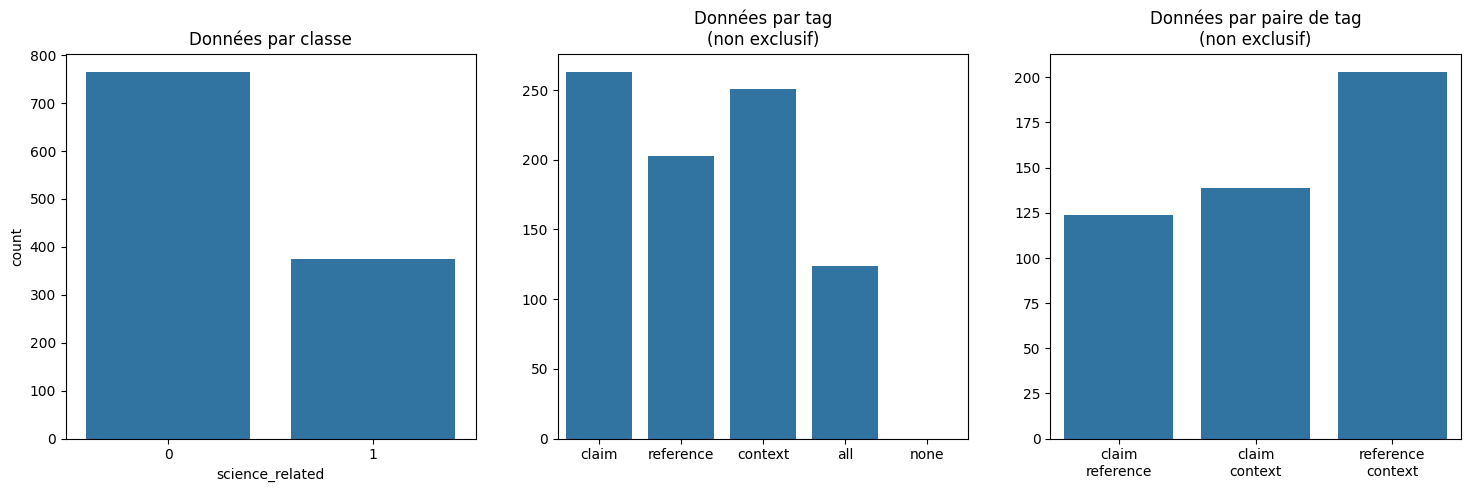

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(18, 5))

sns.countplot(data=data, x="science_related", ax=ax1)

n_tags = {t: data[t].value_counts().get(1.) for t in tags}
n_tags["all"] = data.apply(lambda x: sum([x[t] for t in tags]) == 3., axis=1).value_counts().get(True)
n_tags["none"] = data.apply(lambda x: x["science_related"] and sum([x[t] for t in tags]) == 0., axis=1).value_counts().get(True)

sns.barplot(data=list(n_tags.values()), ax=ax2)
ax2.set_xticks(range(len(n_tags)), labels=list(n_tags.keys()))

n_tags_2 = {t1 + "\n" + t2: data[(data[t1] == 1.)][t2].value_counts().get(1.0) for t1, t2 in combinations(tags, 2)}

sns.barplot(data=list(n_tags_2.values()), ax=ax3)
ax3.set_xticks(range(len(n_tags_2)), labels=list(n_tags_2.keys()))

ax1.set_title("Données par classe")
ax2.set_title("Données par tag\n(non exclusif)")
ax3.set_title("Données par paire de tag\n(non exclusif)")

plt.show()

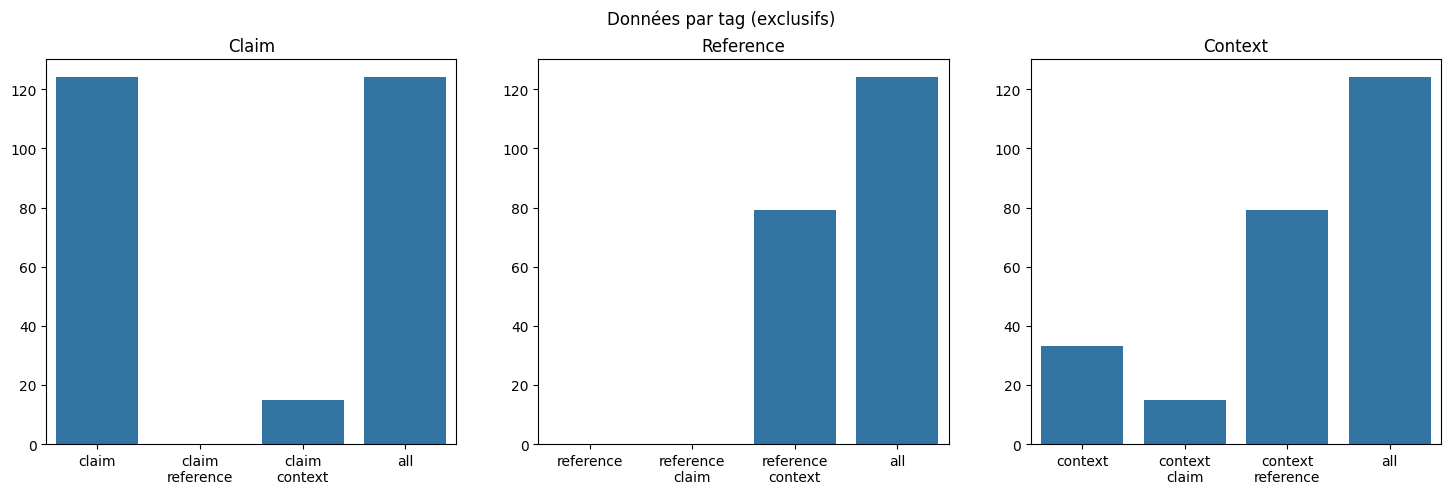

In [16]:
n_claim_ex = {}
n_claim_ex["claim"] = len(data[(data["claim"] == 1.) & (data["reference"] == 0.) & (data["context"] == 0.)])
n_claim_ex["claim\nreference"] = len(data[(data["claim"] == 1.) & (data["reference"] == 1.) & (data["context"] == 0.)])
n_claim_ex["claim\ncontext"] = len(data[(data["claim"] == 1.) & (data["reference"] == 0.) & (data["context"] == 1.)])
n_claim_ex["all"] = len(data[(data["claim"] == 1.) & (data["reference"] == 1.) & (data["context"] == 1.)])

n_ref_ex = {}
n_ref_ex["reference"] = len(data[(data["claim"] == 0.) & (data["reference"] == 1.) & (data["context"] == 0.)])
n_ref_ex["reference\nclaim"] = len(data[(data["claim"] == 1.) & (data["reference"] == 1.) & (data["context"] == 0.)])
n_ref_ex["reference\ncontext"] = len(data[(data["claim"] == 0.) & (data["reference"] == 1.) & (data["context"] == 1.)])
n_ref_ex["all"] = len(data[(data["claim"] == 1.) & (data["reference"] == 1.) & (data["context"] == 1.)])

n_cont_ex = {}
n_cont_ex["context"] = len(data[(data["claim"] == 0.) & (data["reference"] == 0.) & (data["context"] == 1.)])
n_cont_ex["context\nclaim"] = len(data[(data["claim"] == 1.) & (data["reference"] == 0.) & (data["context"] == 1.)])
n_cont_ex["context\nreference"] = len(data[(data["claim"] == 0.) & (data["reference"] == 1.) & (data["context"] == 1.)])
n_cont_ex["all"] = len(data[(data["claim"] == 1.) & (data["reference"] == 1.) & (data["context"] == 1.)])

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(18, 5))

sns.barplot(data=list(n_claim_ex.values()), ax=ax1)
ax1.set_xticks(range(len(n_claim_ex)), labels=list(n_claim_ex.keys()))
ax1.set_title("Claim")

sns.barplot(data=list(n_ref_ex.values()), ax=ax2)
ax2.set_xticks(range(len(n_cont_ex)), labels=list(n_ref_ex.keys()))
ax2.set_title("Reference")

sns.barplot(data=list(n_cont_ex.values()), ax=ax3)
ax3.set_xticks(range(len(n_cont_ex)), labels=list(n_cont_ex.keys()))
ax3.set_title("Context")

plt.suptitle("Données par tag (exclusifs)")
plt.show()

In [17]:
def plot_by_param(param):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.countplot(data=data, x="science_related", hue=param, ax=ax1)
    for container in ax1.containers:
        ax1.bar_label(container)
    ax1.set_xlabel("Science Related")
    ax1.set_ylabel("Nombre de données")

    props = data[data[param]]["science_related"].value_counts().values / data["science_related"].value_counts().values * 100
    sns.barplot(data=props.round(0), ax=ax2)
    ax2.bar_label(ax2.containers[0])
    ax2.set_ylabel(f"Proportion de donné avec {param} (en %)")
    ax2.set_xlabel("Science Related")
    ax2.set_ylim(0, 100)

    plt.suptitle("Données par classe avec " + param)
    plt.show()

### Langue

,text,science_related,claim,reference,context,lang
18,"""@TheFactsBook: Drinking chocolate milk has be...",1,1.0,0.0,0.0,af
37,Lemme stop talking anus,0,0.0,0.0,0.0,da
232,BEAGLE 2 http://t.co/H35j3jdcVb THEY FOUND THE...,0,0.0,0.0,0.0,vi
251,Lol niggas in dark movie scenes need more ligh...,0,0.0,0.0,0.0,af
307,Political science https://t.co/Bl5B3cDsRI,0,0.0,0.0,0.0,it
420,Magnetic resonance imaging findings in giant c...,1,0.0,1.0,1.0,it
621,im gonna be an economist,0,0.0,0.0,0.0,it
830,Global mobile group supports disaster response...,0,0.0,0.0,0.0,fr
861,Latex dresses are a must 👧💗💕 https://t.co/h6De...,0,0.0,0.0,0.0,fr
941,RTs are a helluva drug,1,1.0,0.0,0.0,et


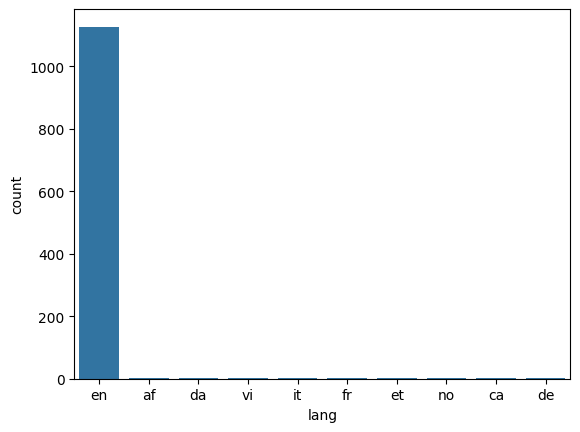

In [18]:
data["lang"] = data.apply(lambda x: langdetect.detect(x["text"]), axis=1)
sns.countplot(data=data, x="lang");
data[data["lang"] != "en"]

### Fautes d'orthographe

computed


<Axes: xlabel='miss', ylabel='Count'>

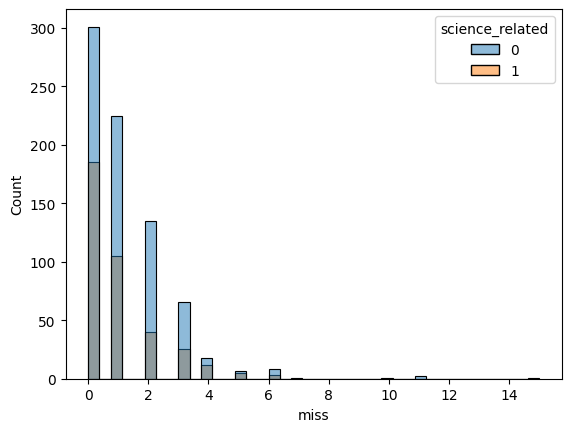

In [12]:
from spellchecker import SpellChecker
import spacy

nlp = spacy.load("en_core_web_sm")
spell = SpellChecker()

def get_n_miss(x):
    tokens = [t.text for t in nlp(x['text']) if t.is_alpha]
    misspelled = spell.unknown(tokens)
    return len(misspelled)

data['miss'] = data.apply(get_n_miss, axis=1)
print("computed")
sns.histplot(data=data, x='miss', hue='science_related')

<Axes: xlabel='?', ylabel='Count'>

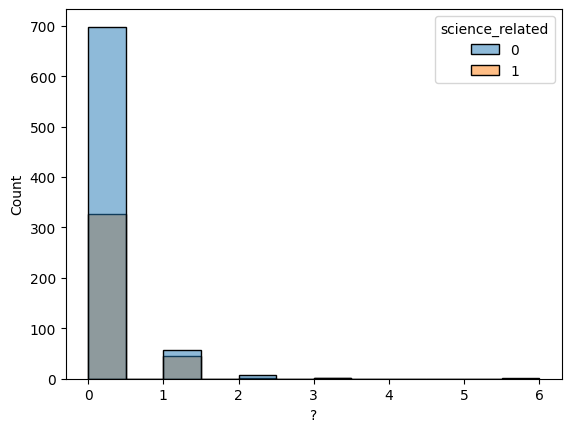

In [20]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_n_punct(x, p):
    return x["text"].count(p)

data['?'] = data.apply(lambda x: get_n_punct(x, "?"), axis=1)
sns.histplot(data=data, x='?', hue='science_related')

### Emojis

Très peu de tweets scientifiques possèdes des émojis. Parmis ceux qui en possède, 5/6 ont le tag claim.

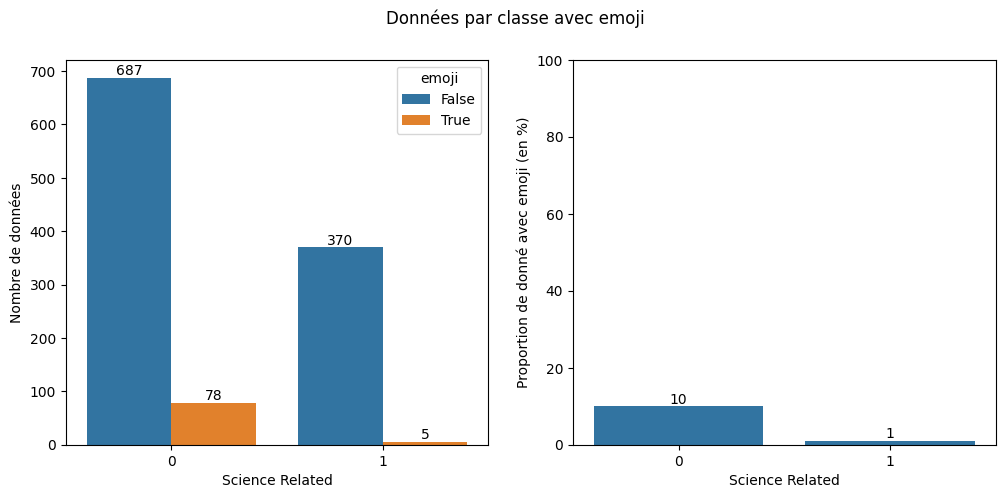

['😂', '✨', '💯', '💙', '➡', '👁', '🙂']


,claim,reference,context
393,1.0,0.0,0.0
880,1.0,0.0,0.0
903,1.0,0.0,0.0
1131,1.0,0.0,0.0
1230,0.0,1.0,1.0


In [ ]:
emoji_pattern = r"(?<!http)(?:[:=;][oO\-]?[D\)\]\(\]\\OpP])"

data["emoji"] = data.apply(lambda x: any([emoji.is_emoji(c) for c in x["text"]]), axis=1)
plot_by_param("emoji")

print(emoji.distinct_emoji_list("".join(data[(data["science_related"] == 1.) & (data["emoji"])]["text"].values)))
data[(data["science_related"] == 1.) & (data["emoji"])][tags]

### URLs

Une grande proportion des tweets scientifiques possèdes un URL.

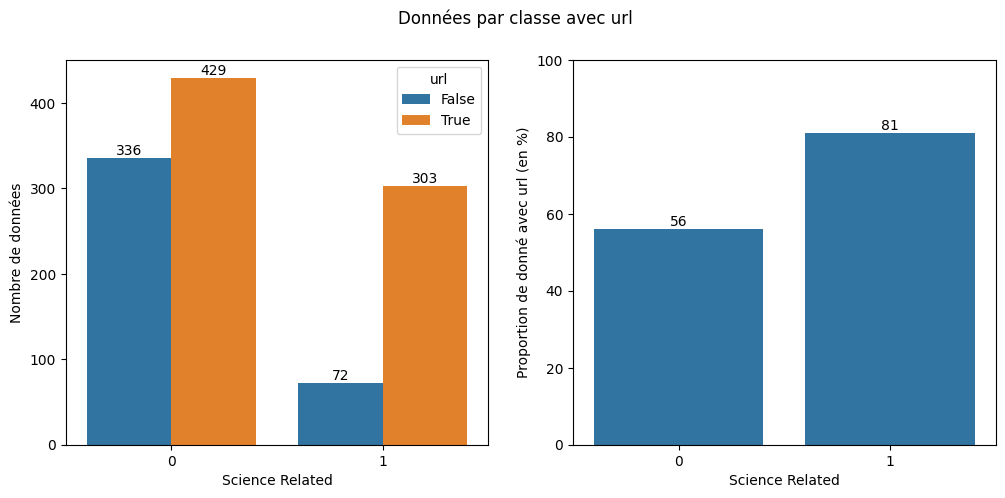

In [ ]:
url_pattern = r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+'
data["url"] = data.apply(lambda x: re.search(url_pattern, x["text"]) is not None, axis=1)
plot_by_param("url")

### Mention

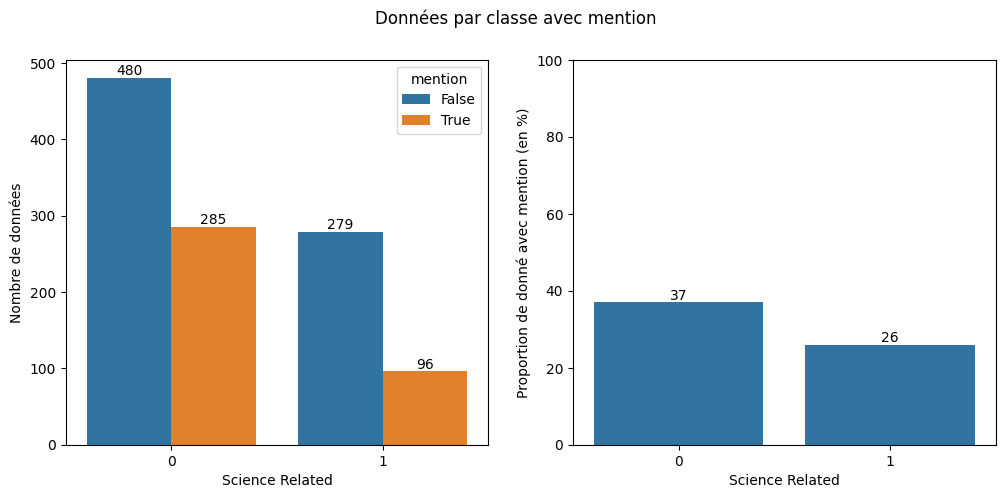

In [ ]:
mention_pattern = r'(?:@[\w_]+)'
data["mention"] = data.apply(lambda x: re.search(mention_pattern, x["text"]) is not None, axis=1)
plot_by_param("mention")

### Nombres

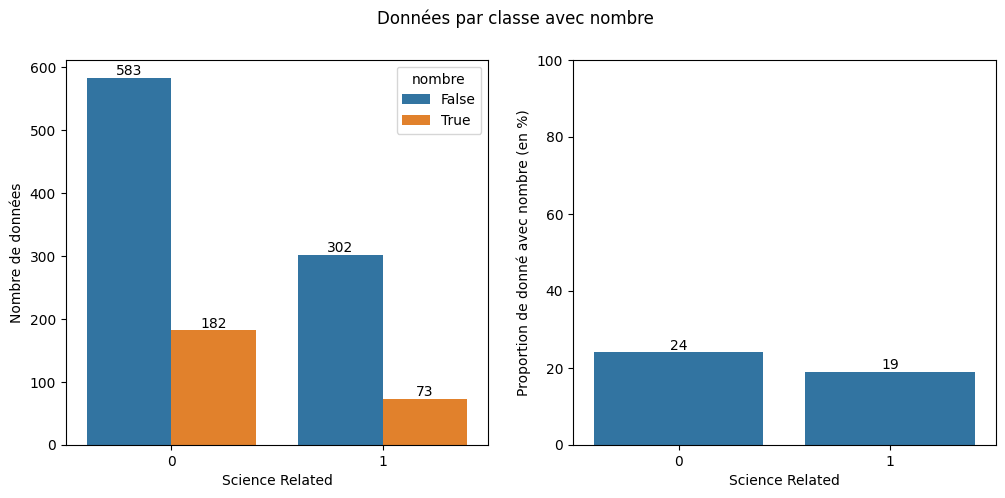

In [ ]:
def has_number(x):
    for p in sent_tokenize(x["text"]):
        if any(t[1] == "CD" for t in pos_tag(word_tokenize(p))):
            return True
    return False

data["nombre"] = data.apply(has_number, axis=1)
plot_by_param("nombre")

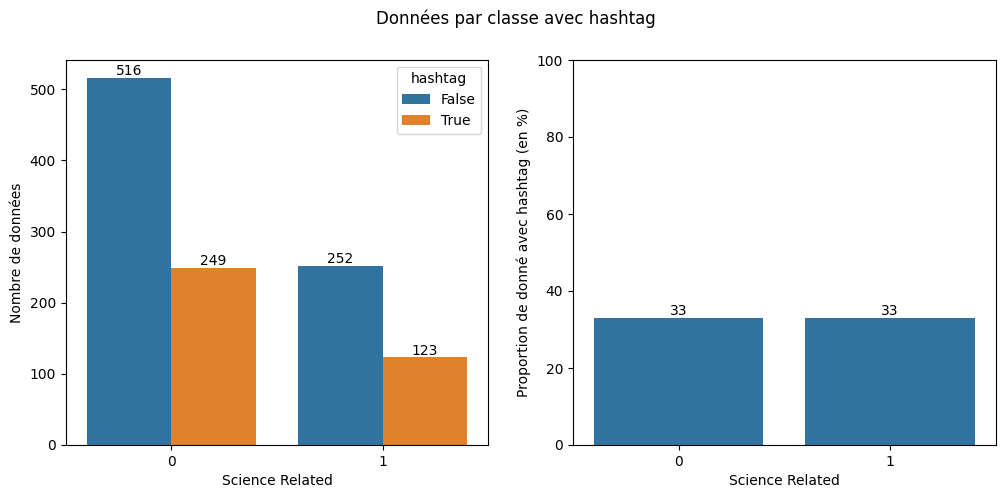

In [ ]:
hashtag_pattern = r'(?:\#+[\w_]+[\w\'_\-]*[\w_]+)'
data["hashtag"] = data.apply(lambda x: re.search(hashtag_pattern, x["text"]) is not None, axis=1)
plot_by_param("hashtag")